# Lab Instructions

You have been hired by James Cameron to create profiles of two characters for a reboot of the Titanic Movie: one that is most likely to survive the sinking and one that is least likely to survive.  Mr. Cameron wants this reboot to be as historically accurate as possible, so your profile of each character should be backed up with data and visualizations.

Each character profile should include information on their:
* Age, fare
* Sex
* Passenger class
* Travel companions (including both parents/children and siblings/spouse)
* Port of departure (indicated by the Embarked feature in the dataset)

For quantitative features like `Age` and `Fare`, you will need to use the `.loc` method we learned in class (or something similar) to place individuals in categories.  How you choose to do this is up to you, but make sure you explain your reasoning.

You should include at least one visualization for each element of the character profile (age, sex, passenger class, etc.) as evidence.

After you have developed your two character profiles, use your Pandas data wrangling skills to identify at least one real passenger in the dataset that fits each profile.  Print out the names of these individuals.  Look them up in [Encyclopeida Titanica](https://www.encyclopedia-titanica.org/) (or a similar resource).  

Tell Mr. Cameron at least one thing about the real passengers who fit your two character profiles that you learned from an external resource.  You need one interesting fact about a person who fits the profile of "most likely to survive" and one interesting fact about a person who fits the profile of "least likely to surivive".  



In [15]:
import pandas as pd

df = pd.read_csv('titanic_passengers.csv')

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


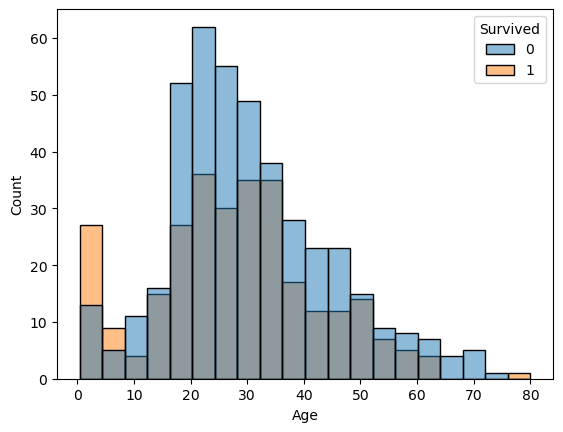

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(x='Age', data=df, hue='Survived')

plt.show()

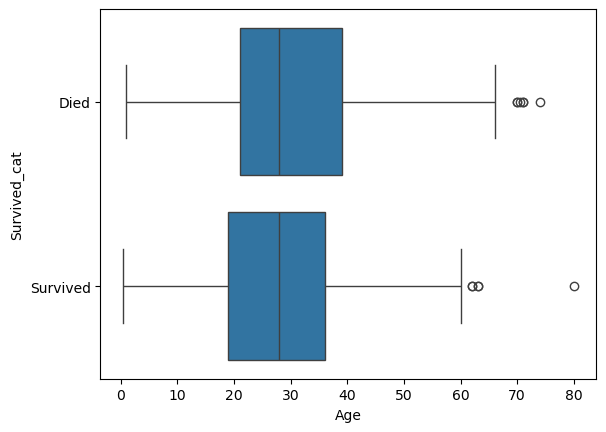

In [9]:
df.loc[df['Survived'] == 0, 'Survived_cat'] = 'Died'
df.loc[df['Survived'] == 1, 'Survived_cat'] = 'Survived'

sns.boxplot(x='Age', data=df, y='Survived_cat')
plt.show()

In [11]:
df['Survived'].dtype

dtype('int64')

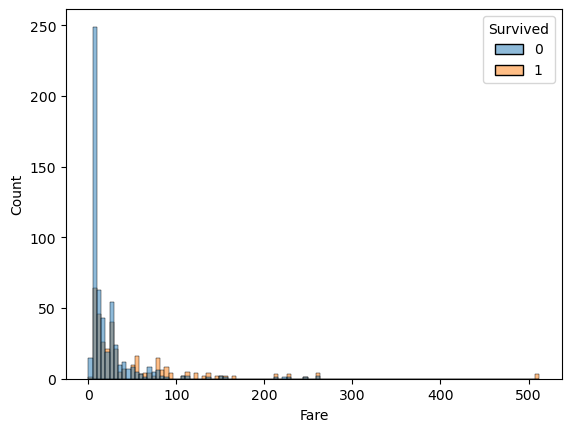

In [13]:
sns.histplot(x='Fare', data=df, hue='Survived')

plt.show()

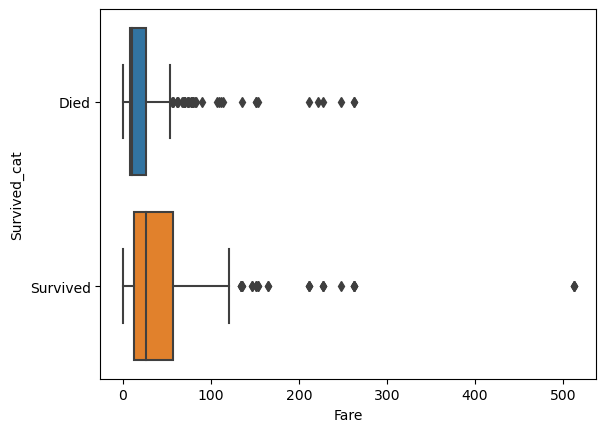

In [8]:
sns.boxplot(x='Fare', data=df, y='Survived_cat')

plt.show()

In [81]:
# Age groups: based on common life stages and Titanic context (“women & children first”)
df['AgeGroup'] = 'Unknown'
df.loc[(df['Age'] >= 0) & (df['Age'] <= 12), 'AgeGroup'] = 'Child (0–12)'
df.loc[(df['Age'] >= 13) & (df['Age'] <= 17), 'AgeGroup'] = 'Teen (13–17)'
df.loc[(df['Age'] >= 18) & (df['Age'] <= 29), 'AgeGroup'] = 'Young Adult (18–29)'
df.loc[(df['Age'] >= 30) & (df['Age'] <= 49), 'AgeGroup'] = 'Adult (30–49)'
df.loc[df['Age'] >= 50, 'AgeGroup'] = 'Senior (50+)'


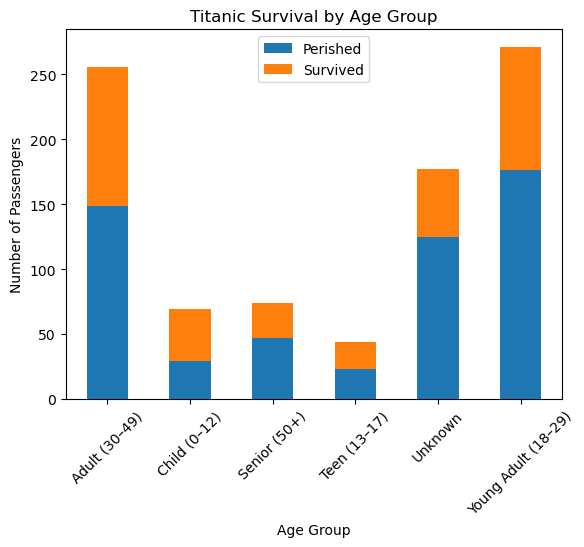

In [91]:
cross_tab_age = pd.crosstab(df['AgeGroup'], df['Survived'])
cross_tab_age.plot(kind='bar', stacked=True,
                   title='Titanic Survival by Age Group',
                   ylabel='Number of Passengers')

plt.xticks(rotation=45)
plt.legend(['Perished','Survived'])
plt.xlabel('Age Group')
plt.show()

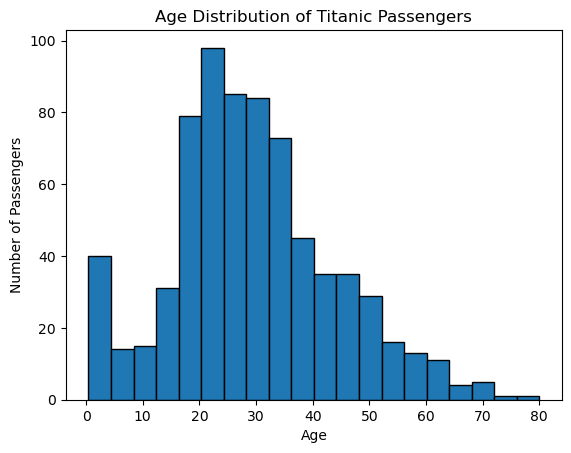

In [93]:
df['Age'].plot(kind='hist', bins=20, edgecolor='black',
               title='Age Distribution of Titanic Passengers')

plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.show()

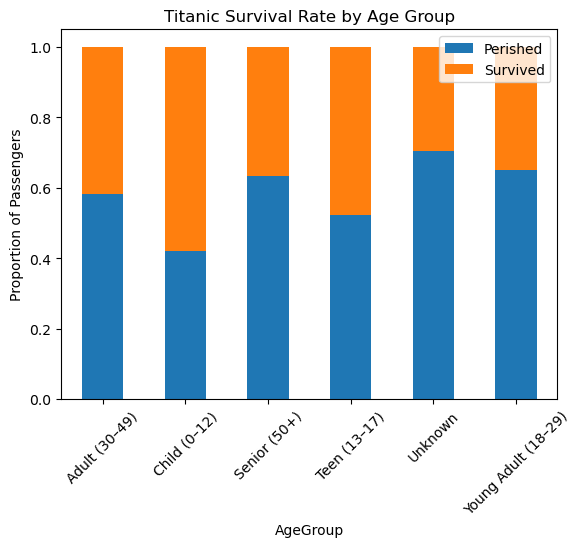

In [95]:
(cross_tab_age.div(cross_tab_age.sum(axis=1), axis=0)
              .plot(kind='bar', stacked=True,
                    title='Titanic Survival Rate by Age Group'))

plt.xticks(rotation=45)
plt.ylabel('Proportion of Passengers')
plt.legend(['Perished','Survived'])
plt.show()


In [85]:
q1 = df['Fare'].quantile(0.25)
q3 = df['Fare'].quantile(0.75)

df['FareBucket'] = 'Unknown'
df.loc[df['Fare'] <= q1, 'FareBucket'] = f'Low (≤ {q1:.2f})'
df.loc[(df['Fare'] > q1) & (df['Fare'] <= q3), 'FareBucket'] = f'Mid ({q1:.2f}–{q3:.2f})'
df.loc[df['Fare'] > q3, 'FareBucket'] = f'High (> {q3:.2f})'

In [97]:
cross_tab_fare = pd.crosstab(df['FareBucket'], df['Survived'])
print(cross_tab_fare)  # this prints the new "data chart"


Survived            0    1
FareBucket                
High (> 31.00)     93  129
Low (≤ 7.91)      179   44
Mid (7.91–31.00)  277  169


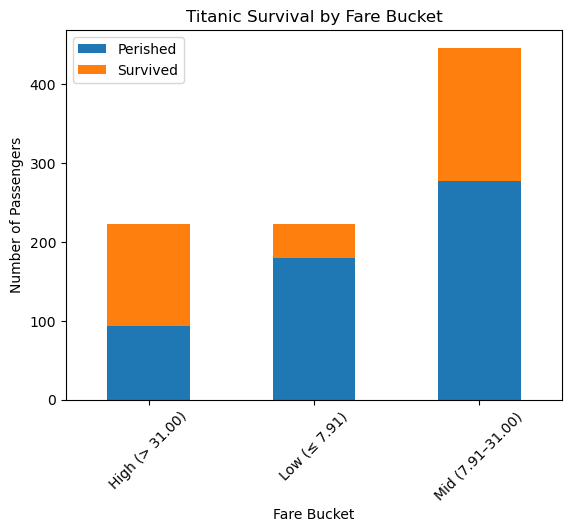

In [99]:
cross_tab_fare.plot(kind='bar', stacked=True,
                    title='Titanic Survival by Fare Bucket',
                    ylabel='Number of Passengers')

plt.xticks(rotation=45)
plt.legend(['Perished','Survived'])
plt.xlabel('Fare Bucket')
plt.show()


In [59]:
#calculate the cross-tab
cross_tab = pd.crosstab(df['Sex'],df['Survived'])

#Save it to its own dataframe using .DataFrame method
cross_tab_df=pd.DataFrame(cross_tab)

cross_tab_df


Survived,0,1
Sex,,
female,81,233
male,468,109


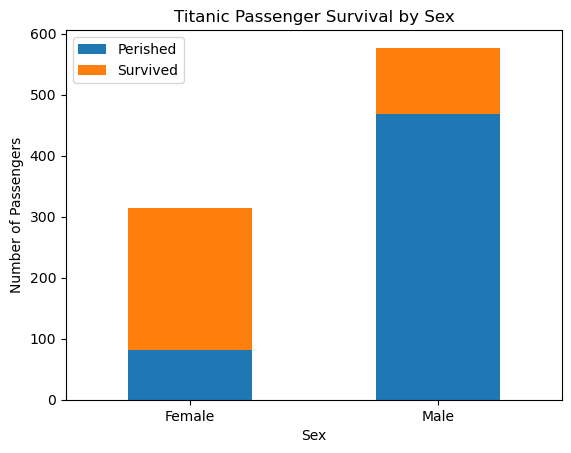

In [101]:
#make the figure
cross_tab_df.plot(kind='bar', stacked=True, title='Titanic Passenger Survival by Sex', ylabel='Number of Passengers')

#This data structure with brackets is a list. We are going to provide matplotlib with a list of labels for our legend.
current_lables=[0,1]
custom_lables=['Female','Male']
plt.xticks(current_lables, custom_lables, rotation=360)

#Create more descriptive legend labels
custom_legend_labels=['Perished','Survived']
plt.legend(custom_legend_labels)

#this prints the plot
plt.show()

In [103]:
cross_tab_pclass = pd.crosstab(df['Pclass'], df['Survived'])
cross_tab_pclass


Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


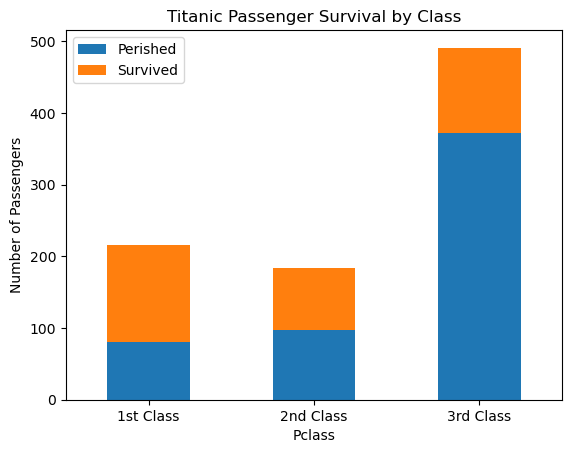

In [105]:
cross_tab_pclass.plot(kind='bar', stacked=True, title='Titanic Passenger Survival by Class',ylabel='Number of Passengers')

plt.xticks([0,1,2], ['1st Class','2nd Class','3rd Class'], rotation=0)
plt.legend(['Perished','Survived'])
plt.show()


In [107]:
df['FamilySize'] = df['SibSp'] + df['Parch']
cross_tab_family = pd.crosstab(df['FamilySize'], df['Survived'])
cross_tab_family


Survived,0,1
FamilySize,,
0,374,163
1,72,89
2,43,59
3,8,21
4,12,3
5,19,3
6,8,4
7,6,0
10,7,0


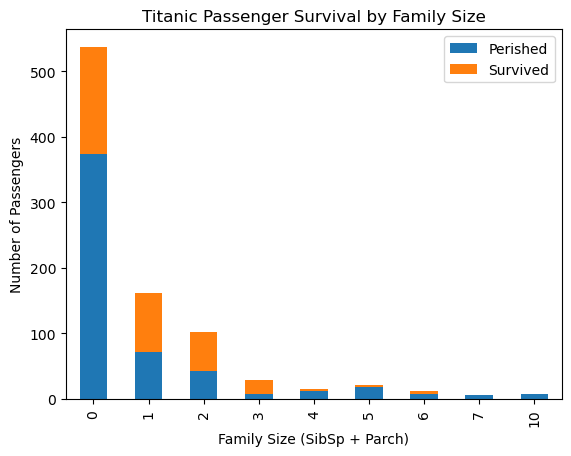

In [109]:
cross_tab_family.plot(kind='bar', stacked=True, title='Titanic Passenger Survival by Family Size', ylabel='Number of Passengers')

plt.legend(['Perished','Survived'])
plt.xlabel('Family Size (SibSp + Parch)')
plt.show()


In [111]:
cross_tab_embarked = pd.crosstab(df['Embarked'], df['Survived'])
cross_tab_embarked


Survived,0,1
Embarked,,
C,75,93
Q,47,30
S,427,217


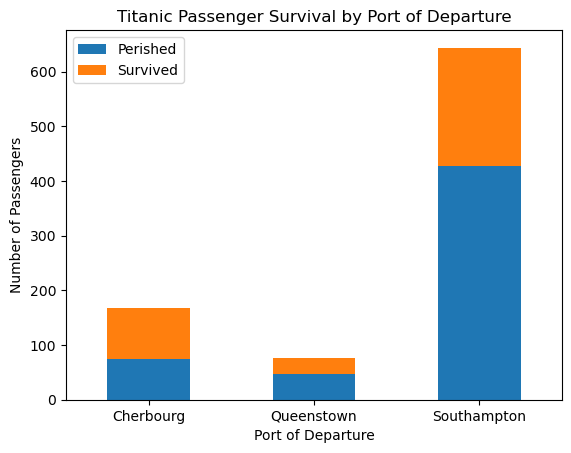

In [113]:
cross_tab_embarked.plot(kind='bar', stacked=True,
                        title='Titanic Passenger Survival by Port of Departure',
                        ylabel='Number of Passengers')

plt.xticks([0,1,2], ['Cherbourg','Queenstown','Southampton'], rotation=0)
plt.legend(['Perished','Survived'])
plt.xlabel('Port of Departure')
plt.show()


In [136]:
# Most likely to survive: female, 1st class, survived, high fare, small family (0–3)
most_likely_filter = (
    (df['Survived'] == 1) &
    (df['Sex'] == 'female') &
    (df['Pclass'] == 1) &
    (df['FareBucket'].str.startswith('High')) &
    (df['FamilySize'] <= 3)
)

# Least likely to survive: male, 3rd class, perished, low fare, traveled alone, Southampton
least_likely_filter = (
    (df['Survived'] == 0) &
    (df['Sex'] == 'male') &
    (df['Pclass'] == 3) &
    (df['FareBucket'].str.startswith('Low')) &
    (df['FamilySize'] == 0) &
    (df['Embarked'] == 'S')
)

cols = ['Name','Sex','Age','AgeGroup','Pclass','FamilySize','Fare','FareBucket','Embarked','Survived']

candidates_most = df.loc[most_likely_filter, cols]
candidates_least = df.loc[least_likely_filter, cols]

print("=== Most Likely to Survive (Top 10) ===")
print(candidates_most.head(10))

print("\n=== Least Likely to Survive (Top 10) ===")
print(candidates_least.head(10))

=== Most Likely to Survive (Top 10) ===
                                                  Name     Sex   Age  \
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0   
31      Spencer, Mrs. William Augustus (Marie Eugenie)  female   NaN   
52            Harper, Mrs. Henry Sleeper (Myna Haxtun)  female  49.0   
61                                 Icard, Miss. Amelie  female  38.0   
151                  Pears, Mrs. Thomas (Edith Wearne)  female  22.0   
166             Chibnall, Mrs. (Edith Martha Bowerman)  female   NaN   
195                               Lurette, Miss. Elise  female  58.0   
215                            Newell, Miss. Madeleine  female  31.0   
218                              Bazzani, Miss. Albina  female  32.0   

                AgeGroup  Pclass  FamilySize      Fare      FareBucket  \
1          Adult (30–49)       1           1   71.2833  High (> 31.00)   
3          Adult (3

In [115]:
survivor = df[df['Survived'] == 1].iloc[0]
perished = df[df['Survived'] == 0].iloc[0]


fields = ['Name','Sex','Age','AgeGroup','Pclass','SibSp','Parch','FamilySize','Fare','FareBucket','Embarked','Survived']
survivor_profile = survivor[fields].to_dict()
perished_profile = perished[fields].to_dict()

survivor_profile, perished_profile

({'Name': 'Cumings, Mrs. John Bradley (Florence Briggs Thayer)',
  'Sex': 'female',
  'Age': 38.0,
  'AgeGroup': 'Adult (30–49)',
  'Pclass': 1,
  'SibSp': 1,
  'Parch': 0,
  'FamilySize': 1,
  'Fare': 71.2833,
  'FareBucket': 'High (> 31.00)',
  'Embarked': 'C',
  'Survived': 1},
 {'Name': 'Braund, Mr. Owen Harris',
  'Sex': 'male',
  'Age': 22.0,
  'AgeGroup': 'Young Adult (18–29)',
  'Pclass': 3,
  'SibSp': 1,
  'Parch': 0,
  'FamilySize': 1,
  'Fare': 7.25,
  'FareBucket': 'Low (≤ 7.91)',
  'Embarked': 'S',
  'Survived': 0})

Cumings, Mrs. John Bradley (Florence Briggs Thayer) was a 29-year-old woman traveling first class from Cherbourg with a high-fare ticket. She matched the profile of most likely to survive. According to Encyclopedia Titanica, she escaped in lifeboat 4 and later provided testimony to the U.S. Senate inquiry into the disaster.

One passenger who fit the ‘least likely to survive’ profile was Braund, Mr. Owen Harris. He was a 22-year-old male in third class who paid a very low fare of £7.25 and boarded at Southampton. He traveled with one companion and, like many other men in steerage, he did not survive. According to Encyclopedia Titanica, he was a butcher from Bridgerule, Devon, traveling with his father to start a new life in America.